In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df_airports    = pd.read_csv('Airports Data.csv')
df_bags        = pd.read_csv('Bag+Level+Data.csv')
df_flights     = pd.read_csv('Flight Level Data.csv')
df_pnr_remarks = pd.read_csv('PNR Remark Level Data.csv')
df_pnr_flights = pd.read_csv('PNR+Flight+Level+Data.csv')

# Data Cleaning

In [6]:
all_dfs= {
    "bags": df_bags,
    "flights": df_flights,
    "pnr_remarks": df_pnr_remarks,
    "pnr_flights": df_pnr_flights
}

In [7]:
for name,df in all_dfs.items():
    print(f"--- Cleaning and Inspecting: {name} ---")
    print("\nInfo:")
    df.info()
    print("\nMissing Values:")
    print(df.isnull().sum())
    print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")
    print("-" * 30 + "\n")
    

--- Cleaning and Inspecting: bags ---

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687245 entries, 0 to 687244
Data columns (total 8 columns):
 #   Column                            Non-Null Count   Dtype 
---  ------                            --------------   ----- 
 0   company_id                        687245 non-null  object
 1   flight_number                     687245 non-null  int64 
 2   scheduled_departure_date_local    687245 non-null  object
 3   scheduled_departure_station_code  687245 non-null  object
 4   scheduled_arrival_station_code    687245 non-null  object
 5   bag_tag_unique_number             687245 non-null  object
 6   bag_tag_issue_date                687245 non-null  object
 7   bag_type                          687245 non-null  object
dtypes: int64(1), object(7)
memory usage: 41.9+ MB

Missing Values:
company_id                          0
flight_number                       0
scheduled_departure_date_local      0
scheduled_departure_station_code 

## Removing Duplicates from bags dataset

In [9]:
print(f"Number of rows in df_bags before cleaning: {len(df_bags)}")

df_bags.drop_duplicates(inplace=True)

print(f"Number of rows in df_bags after cleaning: {len(df_bags)}")

Number of rows in df_bags before cleaning: 687245
Number of rows in df_bags after cleaning: 686952


In [10]:
df_bags.duplicated().sum()

0

## Converting into correct datatypes

### bags

In [13]:
df_bags['scheduled_departure_date_local'] = pd.to_datetime(df_bags['scheduled_departure_date_local'])
df_bags['bag_tag_issue_date'] = pd.to_datetime(df_bags['bag_tag_issue_date'])

df_bags['bag_type']=df_bags['bag_type'].astype('category')

### flights

In [15]:
df_flights['scheduled_departure_date_local'] = pd.to_datetime(df_flights['scheduled_departure_date_local'])
df_flights['scheduled_departure_datetime_local'] = pd.to_datetime(df_flights['scheduled_departure_datetime_local'])
df_flights['scheduled_arrival_datetime_local'] = pd.to_datetime(df_flights['scheduled_arrival_datetime_local'])
df_flights['actual_departure_datetime_local'] = pd.to_datetime(df_flights['actual_departure_datetime_local'])
df_flights['actual_arrival_datetime_local'] = pd.to_datetime(df_flights['actual_arrival_datetime_local'])

df_flights['fleet_type'] = df_flights['fleet_type'].astype('category')
df_flights['carrier'] = df_flights['carrier'].astype('category')

### pnr_remarks

In [17]:
df_pnr_remarks['pnr_creation_date'] = pd.to_datetime(df_pnr_remarks['pnr_creation_date'])

df_pnr_remarks['special_service_request']=df_pnr_remarks['special_service_request'].astype('category')

In [18]:
df_pnr_remarks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51698 entries, 0 to 51697
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   record_locator           51698 non-null  object        
 1   pnr_creation_date        51698 non-null  datetime64[ns]
 2   flight_number            51698 non-null  int64         
 3   special_service_request  51698 non-null  category      
dtypes: category(1), datetime64[ns](1), int64(1), object(1)
memory usage: 1.2+ MB


### pnr_flights

In [20]:
df_pnr_flights['scheduled_departure_date_local'] = pd.to_datetime(df_pnr_flights['scheduled_departure_date_local'])
df_pnr_flights['pnr_creation_date'] = pd.to_datetime(df_pnr_flights['pnr_creation_date'])

df_pnr_flights['is_child'] = df_pnr_flights['is_child'].apply(lambda x: 1 if x == 'Y' else 0)
df_pnr_flights['is_stroller_user'] = df_pnr_flights['is_stroller_user'].apply(lambda x: 1 if x == 'Y' else 0)

In [21]:
df_pnr_flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687878 entries, 0 to 687877
Data columns (total 12 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   company_id                        687878 non-null  object        
 1   flight_number                     687878 non-null  int64         
 2   scheduled_departure_date_local    687878 non-null  datetime64[ns]
 3   scheduled_departure_station_code  687878 non-null  object        
 4   scheduled_arrival_station_code    687878 non-null  object        
 5   record_locator                    687878 non-null  object        
 6   pnr_creation_date                 687878 non-null  datetime64[ns]
 7   total_pax                         687878 non-null  int64         
 8   is_child                          687878 non-null  int64         
 9   basic_economy_ind                 687878 non-null  int64         
 10  is_stroller_user                

# 1. Exploratory Data Analysis

### What is the average delay and what percentage of flights depart later than scheduled?

In [24]:
df_flights['departure_delay']=(df_flights['actual_departure_datetime_local']-df_flights['scheduled_departure_datetime_local']).dt.total_seconds()/60

average_delay = df_flights[df_flights['departure_delay']>0]['departure_delay'].mean()
percentage_late_flights = len(df_flights[df_flights['departure_delay']>0])*100/len(df_flights)

print(f" The average departure delay for flights that departed late is: {average_delay:.2f} minutes.")
print(f" The percentage of all flights that departed late is: {percentage_late_flights:.2f}%.")

 The average departure delay for flights that departed late is: 47.06 minutes.
 The percentage of all flights that departed late is: 49.61%.


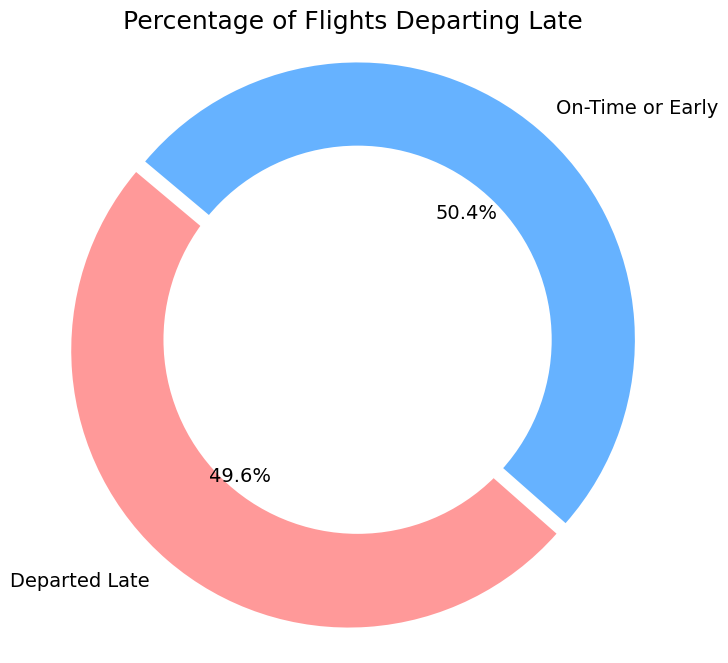

In [25]:
percentage_late_flights = 49.61
percentage_on_time = 100 - percentage_late_flights

# Data for the pie chart
sizes = [percentage_late_flights, percentage_on_time]
labels = ['Departed Late', 'On-Time or Early']
colors = ['#FF9999', '#66B2FF'] # Red for late, blue for on-time
explode = (0.05, 0) 

# Create the pie chart
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',
       startangle=140, colors=colors, textprops={'fontsize': 14})

# Draw a white circle in the center to make it a donut chart
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig.gca().add_artist(centre_circle)

# Set title and ensure it's a circle
ax.axis('equal')
plt.title('Percentage of Flights Departing Late', fontsize=18)

plt.savefig('late_flights_donut_chart.png')
plt.show()

### How many flights have scheduled ground time close to or below the minimum turn mins?

In [27]:
tight_turnaround_flights = df_flights[df_flights['scheduled_ground_time_minutes']<=df_flights['minimum_turn_minutes']]
num_tight_flights = len(tight_turnaround_flights)
percentage_tight_flights = len(tight_turnaround_flights)*100/len(df_flights)

print(f" Number of flights with scheduled ground time at or below the minimum: {num_tight_flights}")
print(f" This represents {percentage_tight_flights:.2f}% of all flights.")

 Number of flights with scheduled ground time at or below the minimum: 652
 This represents 8.05% of all flights.


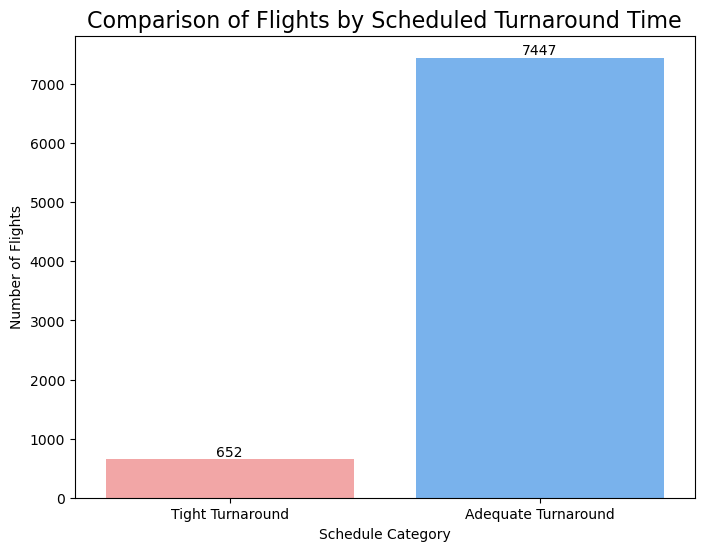

In [28]:
adequate_turnaround_flights = len(df_flights)-num_tight_flights

# Create a DataFrame for plotting
turnaround_data = pd.DataFrame({
    'Category': ['Tight Turnaround', 'Adequate Turnaround'],
    'Number of Flights': [num_tight_flights, adequate_turnaround_flights]
})

# Create the bar chart
plt.figure(figsize=(8, 6))
bar_plot = sns.barplot(x='Category', y='Number of Flights',hue='Category',legend=False, data=turnaround_data, palette=['#FF9999', '#66B2FF'])

# Add text labels on top of each bar
for index, row in turnaround_data.iterrows():
    bar_plot.text(index, row['Number of Flights'], row['Number of Flights'], color='black', ha="center", va='bottom')

# Set titles and labels
plt.title('Comparison of Flights by Scheduled Turnaround Time', fontsize=16)
plt.xlabel('Schedule Category')
plt.ylabel('Number of Flights')

plt.savefig('turnaround_time_comparison.png')
plt.show()

### What is the average ratio of transfer bags vs. checked bags across flights?

In [30]:
flight_identifier = ['flight_number', 'scheduled_departure_date_local']

bags_count_per_flight = df_bags.groupby(flight_identifier)['bag_type'].value_counts().unstack(fill_value=0)
total_transfer_bags = bags_count_per_flight.get('Transfer',0)+bags_count_per_flight.get('Hot Transfer',0)
bags_count_per_flight['transfer_to_checked_ratio'] = total_transfer_bags / (bags_count_per_flight.get('Origin', 0) + 1)
average_ratio = bags_count_per_flight['transfer_to_checked_ratio'].mean()

print(f"The average ratio of transfer bags vs. checked bags is: {average_ratio:.2f}")

The average ratio of transfer bags vs. checked bags is: 2.91


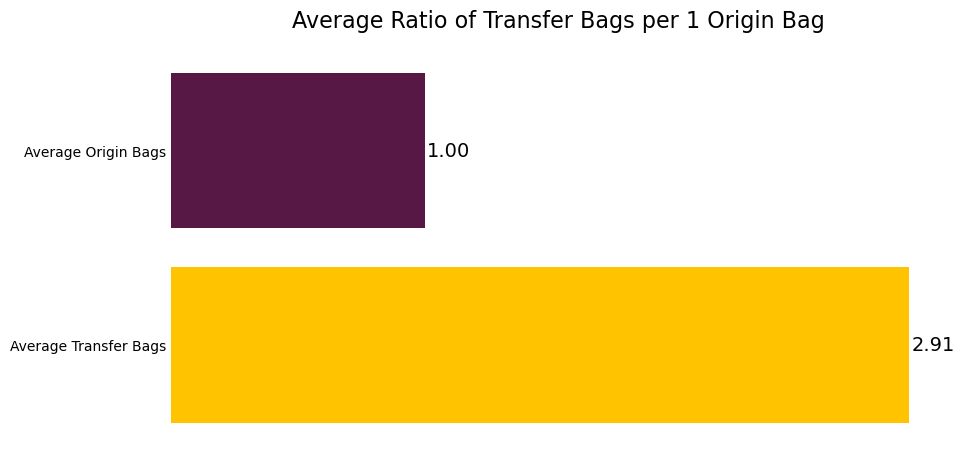

In [31]:

fig, ax = plt.subplots(figsize=(10, 5))

# Data for the bars
categories = ['Average Transfer Bags', 'Average Origin Bags']
values = [average_ratio, 1] # We represent the ratio relative to 1 Origin bag
colors = ['#FFC300', '#581845']

# Create the horizontal bars
bars = ax.barh(categories, values, color=colors)

# Remove chart borders and y-axis ticks
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.tick_params(axis='y', length=0)
ax.tick_params(axis='x', length=0)
ax.get_xaxis().set_ticks([]) # Hide x-axis ticks and labels

# Add text labels to show the values
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.2f}',
            va='center', ha='left', fontsize=14)

# Set title
ax.set_title('Average Ratio of Transfer Bags per 1 Origin Bag', fontsize=16, pad=20)

plt.savefig('baggage_ratio_infographic.png')
plt.show()

### How do passenger loads compare across flights, and do higher loads correlate with operational difficulty?

In [33]:
flight_identifier = ['flight_number', 'scheduled_departure_date_local']

pax_count = df_pnr_flights.groupby(flight_identifier)['total_pax'].sum().reset_index()
df_flights = pd.merge(df_flights, pax_count, on=flight_identifier, how='left')

In [34]:
df_flights.fillna({'total_pax':0},inplace=True)
df_flights['load_factor']=df_flights['total_pax']/df_flights['total_seats']
df_flights.head()

,company_id,flight_number,scheduled_departure_date_local,scheduled_departure_station_code,scheduled_arrival_station_code,scheduled_departure_datetime_local,scheduled_arrival_datetime_local,actual_departure_datetime_local,actual_arrival_datetime_local,total_seats,fleet_type,carrier,scheduled_ground_time_minutes,actual_ground_time_minutes,minimum_turn_minutes,departure_delay,total_pax,load_factor
0,OO,4792,2025-08-04,ORD,ROA,2025-08-04 17:57:00+00:00,2025-08-04 21:04:00+00:00,2025-08-04 18:04:00+00:00,2025-08-04 20:52:00+00:00,76,ERJ-175,Express,42,34,34,7.0,65,0.855263
1,UA,920,2025-08-03,ORD,LHR,2025-08-03 18:05:00+00:00,2025-08-04 08:20:00+00:00,2025-08-03 18:27:00+00:00,2025-08-04 08:06:00+00:00,167,B767-300,Mainline,235,229,145,22.0,171,1.023952
2,UA,1776,2025-08-10,ORD,PHL,2025-08-10 18:20:00+00:00,2025-08-10 21:35:00+00:00,2025-08-10 20:11:00+00:00,2025-08-10 23:26:00+00:00,166,B737-800,Mainline,76,69,51,111.0,180,1.084337
3,OO,5790,2025-08-06,ORD,CRW,2025-08-06 18:20:00+00:00,2025-08-06 21:04:00+00:00,2025-08-06 20:05:00+00:00,2025-08-06 22:42:00+00:00,50,CRJ-200,Express,223,38,29,105.0,55,1.100000
4,UA,1398,2025-08-05,ORD,ATL,2025-08-05 18:20:00+00:00,2025-08-05 21:29:00+00:00,2025-08-05 18:16:00+00:00,2025-08-05 21:49:00+00:00,166,B737-800,Mainline,75,72,51,-4.0,136,0.819277


In [35]:
correlation = df_flights['load_factor'].corr(df_flights['departure_delay'])
print(f" The correlation between passenger load factor and departure delay is: {correlation:.2f}")

 The correlation between passenger load factor and departure delay is: -0.15


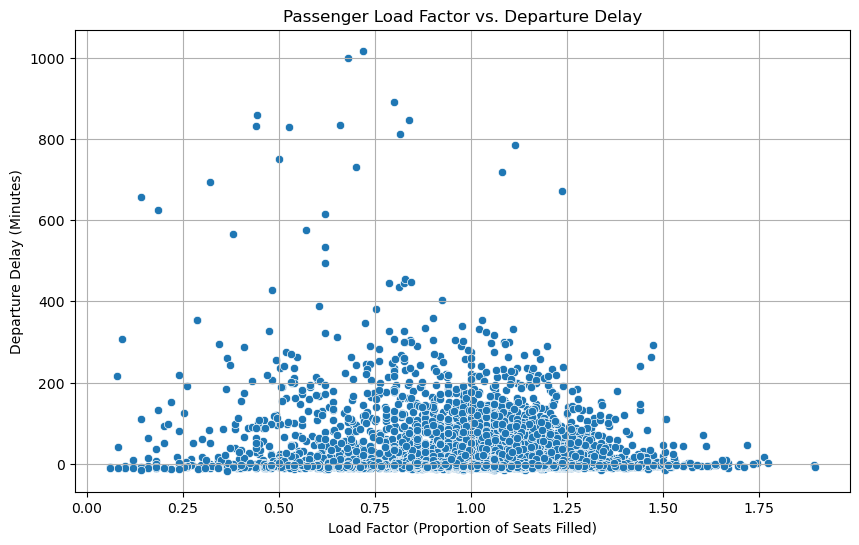

In [36]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_flights, x='load_factor', y='departure_delay')
plt.title('Passenger Load Factor vs. Departure Delay')
plt.xlabel('Load Factor (Proportion of Seats Filled)')
plt.ylabel('Departure Delay (Minutes)')
plt.grid(True)
plt.savefig('load_factor_vs_delay.png')
plt.show()

### Are high special service requests flights also high-delay after controlling for load?

In [38]:
flight_identifier = ['flight_number','scheduled_departure_date_local']
merge_key = ['record_locator', 'pnr_creation_date', 'flight_number']

pnr_dates = df_pnr_flights[merge_key + ['scheduled_departure_date_local']].drop_duplicates()
df_remarks_with_date = pd.merge(df_pnr_remarks, pnr_dates, on=merge_key, how='left')

ssr_counts = df_remarks_with_date.groupby(flight_identifier).size().reset_index(name='ssr_count')

if 'ssr_count' in df_flights.columns:
    df_flights = df_flights.drop(columns=['ssr_count'])

df_flights = pd.merge(df_flights, ssr_counts, on=flight_identifier, how='left')

df_flights['ssr_count'] = df_flights['ssr_count'].fillna(0)

df_flights[['flight_number', 'scheduled_departure_date_local', 'ssr_count']].head()

,flight_number,scheduled_departure_date_local,ssr_count
0,4792,2025-08-04,3.0
1,920,2025-08-03,3.0
2,1776,2025-08-10,0.0
3,5790,2025-08-06,2.0
4,1398,2025-08-05,2.0


In [39]:
df_flights['load_factor_bin'] = pd.cut(df_flights['load_factor'], 
                                     bins=[0, 0.75, 0.9, 1.1], 
                                     labels=['Low (<75%)', 'Medium (75-90%)', 'High (>90%)'])
ssr_median = df_flights['ssr_count'].median()
df_flights['ssr_bin'] = pd.cut(df_flights['ssr_count'], 
                             bins=[-1, ssr_median, df_flights['ssr_count'].max()],
                             labels=['Low', 'High'])
df_flights[['load_factor', 'load_factor_bin', 'ssr_count', 'ssr_bin']].head()

,load_factor,load_factor_bin,ssr_count,ssr_bin
0,0.855263,Medium (75-90%),3.0,High
1,1.023952,High (>90%),3.0,High
2,1.084337,High (>90%),0.0,Low
3,1.100000,High (>90%),2.0,Low
4,0.819277,Medium (75-90%),2.0,Low


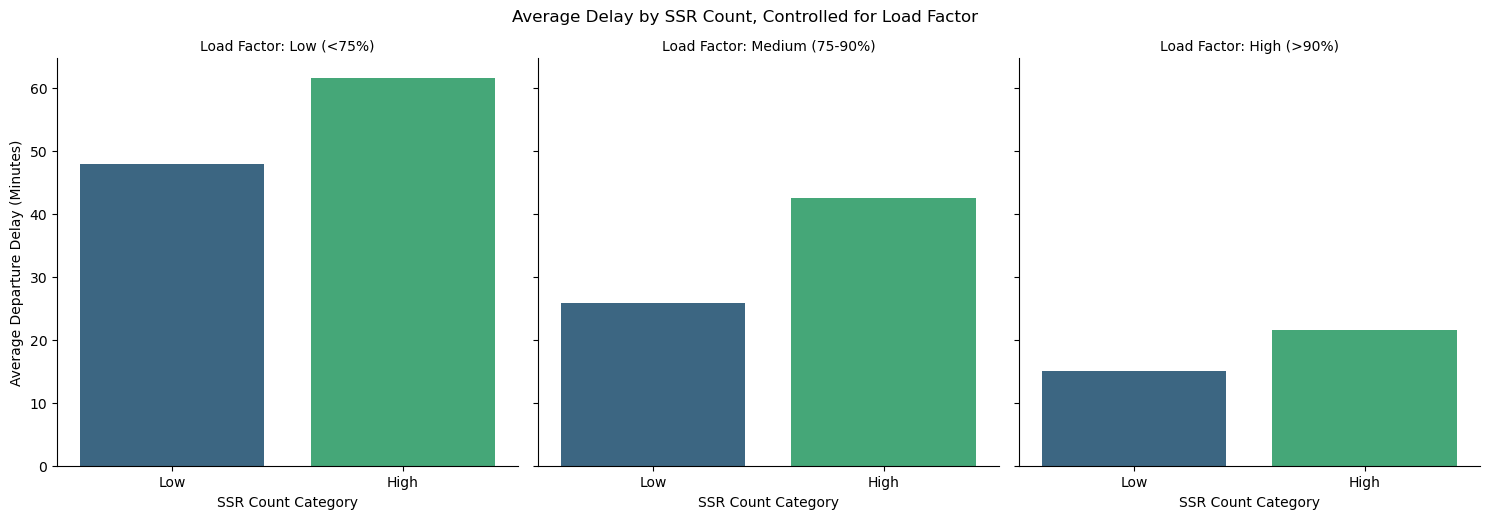

In [40]:
g = sns.catplot(
    data=df_flights, 
    x='ssr_bin', 
    y='departure_delay', 
    col='load_factor_bin', 
    kind='bar', 
    height=5, 
    aspect=1, 
    errorbar=None,
    palette='viridis',
    hue='ssr_bin',
    legend=False
)
g.fig.suptitle('Average Delay by SSR Count, Controlled for Load Factor', y=1.03)
g.set_axis_labels("SSR Count Category", "Average Departure Delay (Minutes)")
g.set_titles("Load Factor: {col_name}")
plt.savefig('ssr_delay_controlled_for_load.png')
plt.show()

# 2. Flight Difficulty Score Development

In [42]:
# --- Step 1: Recalculate Baggage Features ---
flight_identifier = ['flight_number', 'scheduled_departure_date_local']
bag_counts_per_flight = df_bags.groupby(flight_identifier)['bag_type'].value_counts().unstack(fill_value=0)
total_transfer_bags = bag_counts_per_flight.get('Transfer', 0) + bag_counts_per_flight.get('Hot Transfer', 0)
bag_counts_per_flight['transfer_to_origin_ratio'] = total_transfer_bags / (bag_counts_per_flight.get('Origin', 0) + 1)
bag_features = bag_counts_per_flight.reset_index()

# --- Step 2: Aggregate PNR Features ---
pnr_agg_features = df_pnr_flights.groupby(flight_identifier).agg(
    lap_child_count=('lap_child_count', 'sum'),
    is_child=('is_child', 'sum')
).reset_index()

# --- Step 3: Build the Master DataFrame ---
master_df = df_flights.copy()
master_df = pd.merge(master_df, bag_features, on=flight_identifier, how='left')
master_df = pd.merge(master_df, pnr_agg_features, on=flight_identifier, how='left')

# --- Step 4: Engineer Final Features and Select Columns ---
master_df['ground_time_pressure'] = master_df['minimum_turn_minutes'] - master_df['scheduled_ground_time_minutes']
master_df['ground_time_pressure'] = master_df['ground_time_pressure'].clip(lower=0)

feature_columns = [
    'ground_time_pressure',
    'transfer_to_origin_ratio', 
    'load_factor', 
    'ssr_count', 
    'lap_child_count',
    'Hot Transfer'
]

final_features_df = master_df[['flight_number', 'scheduled_departure_date_local'] + feature_columns].copy()

# --- Step 5: Clean Final Features DataFrame ---
for col in feature_columns:
    final_features_df[col] = final_features_df[col].fillna(0)

print("Master Feature DataFrame created successfully!")
final_features_df.head()

Master Feature DataFrame created successfully!


,flight_number,scheduled_departure_date_local,ground_time_pressure,transfer_to_origin_ratio,load_factor,ssr_count,lap_child_count,Hot Transfer
0,4792,2025-08-04,0,5.142857,0.855263,3.0,0,16
1,920,2025-08-03,0,0.582418,1.023952,3.0,1,16
2,1776,2025-08-10,0,0.829787,1.084337,0.0,0,1
3,5790,2025-08-06,0,2.666667,1.100000,2.0,0,0
4,1398,2025-08-05,0,2.550000,0.819277,2.0,0,0


In [43]:
from sklearn.preprocessing import MinMaxScaler

In [44]:
# Define weights for each feature. These can be tuned.
# Based on our EDA, SSRs and ground time pressure seem very important.
weights = {
    'ground_time_pressure': 0.25,
    'ssr_count': 0.25,
    'Hot Transfer': 0.20,
    'transfer_to_origin_ratio': 0.15,
    'load_factor': 0.10,
    'lap_child_count': 0.05
}
feature_columns = list(weights.keys())
df_scaled = final_features_df.copy()

for day, group in df_scaled.groupby('scheduled_departure_date_local'):
     features_to_scale = group[feature_columns]
     scaler = MinMaxScaler()
     scaled_features = scaler.fit_transform(features_to_scale)
     scaled_df = pd.DataFrame(scaled_features, index=group.index, columns=feature_columns)
     df_scaled.loc[group.index, 'difficulty_score'] = (scaled_df * pd.Series(weights)).sum(axis=1)

print("\nDifficulty score calculated successfully!")
df_scaled[['flight_number', 'scheduled_departure_date_local', 'difficulty_score']].head()


Difficulty score calculated successfully!


,flight_number,scheduled_departure_date_local,difficulty_score
0,4792,2025-08-04,0.161595
1,920,2025-08-03,0.191059
2,1776,2025-08-10,0.069091
3,5790,2025-08-06,0.108989
4,1398,2025-08-05,0.085944


In [45]:
# --- Daily Ranking ---
# We group by day and then rank the scores in descending order.
df_scaled['daily_rank'] = df_scaled.groupby('scheduled_departure_date_local')['difficulty_score'].rank(method='dense', ascending=False)

# --- Daily Classification ---
# Define the quantile boundaries and labels for the three tiers.
quantiles = [0, 0.25, 0.75, 1.0]
labels = ['Easy', 'Medium', 'Difficult']

# Use groupby().transform() with pd.qcut to classify flights within each day's score distribution.
df_scaled['difficulty_class'] = df_scaled.groupby('scheduled_departure_date_local')['difficulty_score'] \
                                         .transform(lambda x: pd.qcut(x, q=quantiles, labels=labels, duplicates='drop'))

# --- Display the Final Result ---
print("Daily ranking and classification complete!")

# Sort by day and rank to see the most difficult flights at the top.
final_output = df_scaled[[
    'flight_number', 
    'scheduled_departure_date_local', 
    'difficulty_score', 
    'daily_rank', 
    'difficulty_class'
]].sort_values(by=['scheduled_departure_date_local', 'daily_rank'])
final_output

Daily ranking and classification complete!


,flight_number,scheduled_departure_date_local,difficulty_score,daily_rank,difficulty_class
6984,972,2025-08-01,0.415915,1.0,Difficult
6578,1811,2025-08-01,0.401741,2.0,Difficult
4739,5272,2025-08-01,0.391892,3.0,Difficult
2816,5376,2025-08-01,0.369118,4.0,Difficult
6233,4425,2025-08-01,0.354613,5.0,Difficult
...,...,...,...,...,...
7395,729,2025-08-15,0.035446,552.0,Easy
5819,669,2025-08-15,0.021566,553.0,Easy
4291,1077,2025-08-15,0.015802,554.0,Easy
8094,5027,2025-08-15,0.013187,555.0,Easy


# Post-Analysis & Operational Insights

###  Summarize which destinations consistently show more difficulty.

In [48]:
# We add 'scheduled_arrival_station_code' to the list of columns to keep
final_features_df = master_df[[
    'flight_number', 
    'scheduled_departure_date_local', 
    'scheduled_arrival_station_code'  # Ensure destination is included
] + feature_columns].copy()

# Clean the feature set
for col in feature_columns:
    final_features_df[col] = final_features_df[col].fillna(0)

# --- Step 2: Calculate the Difficulty Score ---
weights = {
    'ground_time_pressure': 0.25, 'ssr_count': 0.25, 'Hot Transfer': 0.20,
    'transfer_to_origin_ratio': 0.15, 'load_factor': 0.10, 'lap_child_count': 0.05
}
feature_columns = list(weights.keys())
df_scaled = final_features_df.copy()

for day, group in df_scaled.groupby('scheduled_departure_date_local'):
    features_to_scale = group[feature_columns]
    scaler = MinMaxScaler()
    scaled_features = scaler.fit_transform(features_to_scale)
    scaled_df = pd.DataFrame(scaled_features, index=group.index, columns=feature_columns)
    df_scaled.loc[group.index, 'difficulty_score'] = (scaled_df * pd.Series(weights)).sum(axis=1)

# --- Step 3: Rank and Classify ---
df_scaled['daily_rank'] = df_scaled.groupby('scheduled_departure_date_local')['difficulty_score'].rank(method='dense', ascending=False)
quantiles = [0, 0.25, 0.75, 1.0]
labels = ['Easy', 'Medium', 'Difficult']
df_scaled['difficulty_class'] = df_scaled.groupby('scheduled_departure_date_local')['difficulty_score'] \
                                         .transform(lambda x: pd.qcut(x, q=quantiles, labels=labels, duplicates='drop'))

# --- Step 4: Run the Final Analysis ---
difficult_flights = df_scaled[df_scaled['difficulty_class'] == 'Difficult']
difficult_destinations = difficult_flights['scheduled_arrival_station_code'].value_counts()

print("Top 10 most consistently difficult destinations:")
difficult_destinations.head(10)

Top 10 most consistently difficult destinations:


scheduled_arrival_station_code
IAH    81
SFO    74
LAX    72
SEA    59
MCO    50
DEN    50
EWR    44
CLE    42
MSN    40
PDX    37
Name: count, dtype: int64

###  What are the common drivers for those flights

In [50]:
# Get the list of the top 5 difficult destinations from your previous output
top_5_destinations = difficult_destinations.head(5).index.tolist()

# Filter the scaled DataFrame to get all data for flights to these top destinations
top_dests_df = df_scaled[df_scaled['scheduled_arrival_station_code'].isin(top_5_destinations)]

# Define the feature columns we want to analyze
driver_feature_columns = [
    'ground_time_pressure',
    'transfer_to_origin_ratio',
    'load_factor',
    'ssr_count',
    'lap_child_count',
    'Hot Transfer'
]

# Calculate the average of these features for the difficult destinations
difficult_drivers = top_dests_df[driver_feature_columns].mean()

# Calculate the overall average for all flights for comparison
overall_averages = df_scaled[driver_feature_columns].mean()

# Create a comparison DataFrame to easily see the differences
driver_comparison_df = pd.DataFrame({
    'Difficult Destinations Average': difficult_drivers,
    'Overall Average': overall_averages
})

# Add a column to see the percentage difference
driver_comparison_df['Difference (%)'] = ((driver_comparison_df['Difficult Destinations Average'] - driver_comparison_df['Overall Average']) / driver_comparison_df['Overall Average']) * 100

# --- Print the result ---
print(f"Analysis of Difficulty Drivers for Top Destinations: {', '.join(top_5_destinations)}")
driver_comparison_df

Analysis of Difficulty Drivers for Top Destinations: IAH, SFO, LAX, SEA, MCO


,Difficult Destinations Average,Overall Average,Difference (%)
ground_time_pressure,7.465008,5.052476,47.749506
transfer_to_origin_ratio,1.056648,3.409056,-69.004664
load_factor,1.138398,1.024236,11.146082
ssr_count,3.474339,2.117669,64.064322
lap_child_count,1.129082,0.693049,62.915350
Hot Transfer,8.665630,5.807137,49.223797


In [51]:
submission_df = df_scaled[[
    'flight_number',
    'scheduled_departure_date_local',
    'scheduled_arrival_station_code',
    'ground_time_pressure',
    'transfer_to_origin_ratio',
    'load_factor',
    'ssr_count',
    'lap_child_count',
    'Hot Transfer',
    'difficulty_score',
    'daily_rank',
    'difficulty_class'
]].copy()

submission_df.to_csv('test_your_name.csv', index=False)

print("Submission CSV file 'test_your_name.csv' created successfully!")

Submission CSV file 'test_your_name.csv' created successfully!


# Some more Important visualizations

## 1. Correlation Heatmap of Key Features


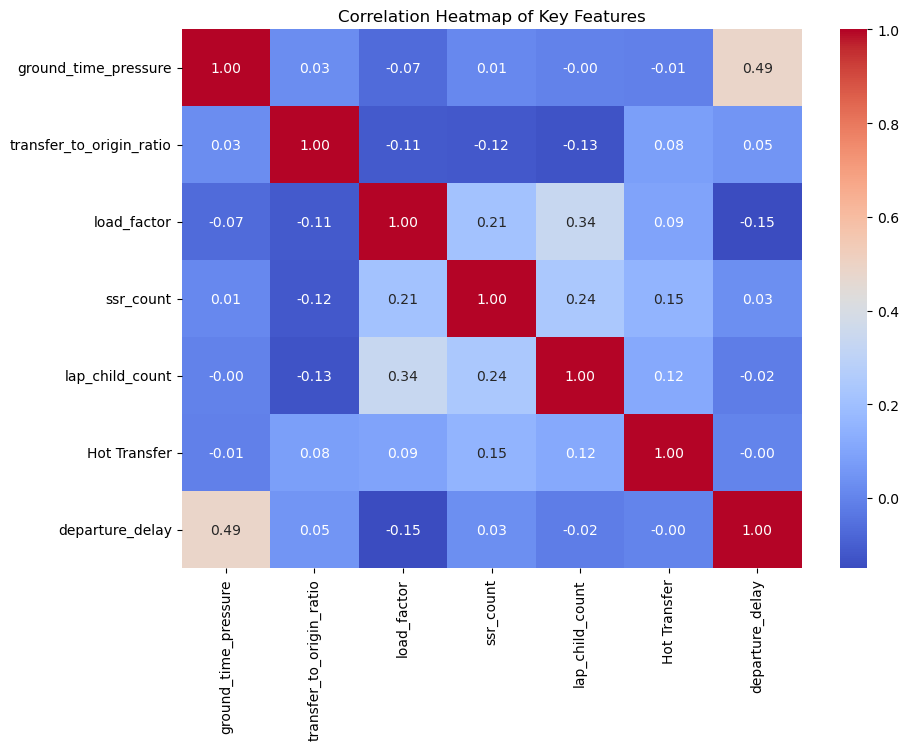

In [54]:

heatmap_features = final_features_df[[
    'ground_time_pressure', 'transfer_to_origin_ratio', 'load_factor',
    'ssr_count', 'lap_child_count', 'Hot Transfer'
]]

heatmap_features = heatmap_features.join(df_flights['departure_delay'])


plt.figure(figsize=(10, 7))
sns.heatmap(heatmap_features.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap of Key Features')
plt.savefig('correlation_heatmap.png')
plt.show()

## 2. Number of Flights by Aircraft Type

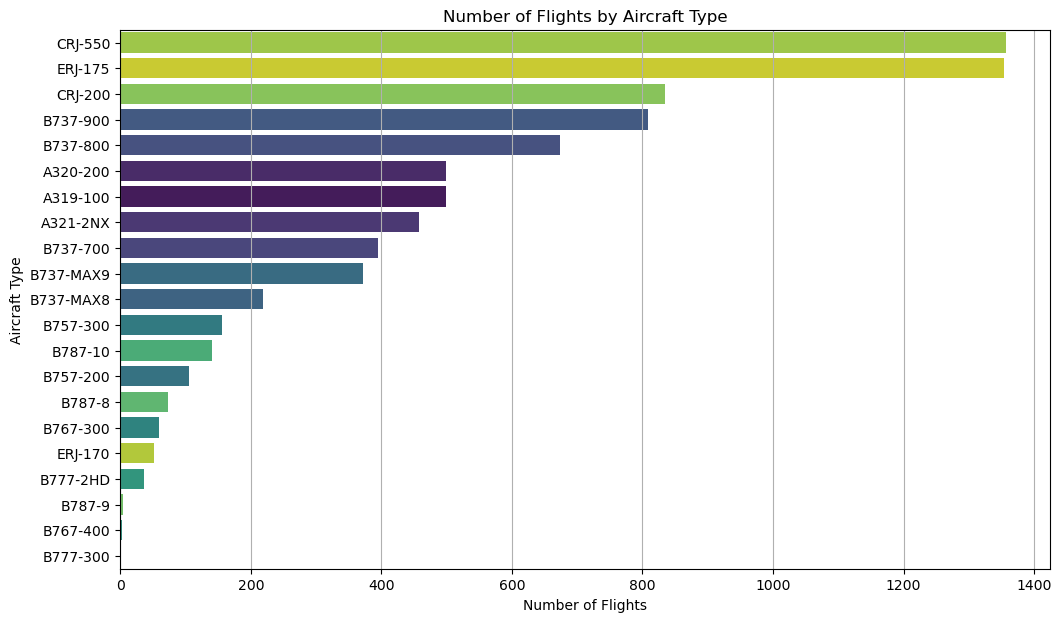

In [56]:
plt.figure(figsize=(12, 7))
sns.countplot(
    y=df_flights['fleet_type'], 
    order=df_flights['fleet_type'].value_counts().index, 
    palette='viridis',
    hue=df_flights['fleet_type'],   
    legend=False                   
)
plt.title('Number of Flights by Aircraft Type')
plt.xlabel('Number of Flights')
plt.ylabel('Aircraft Type')
plt.grid(axis='x')
plt.savefig('flights_by_aircraft.png')
plt.show()

## 3.Breakdown of Flight Difficulty Classes

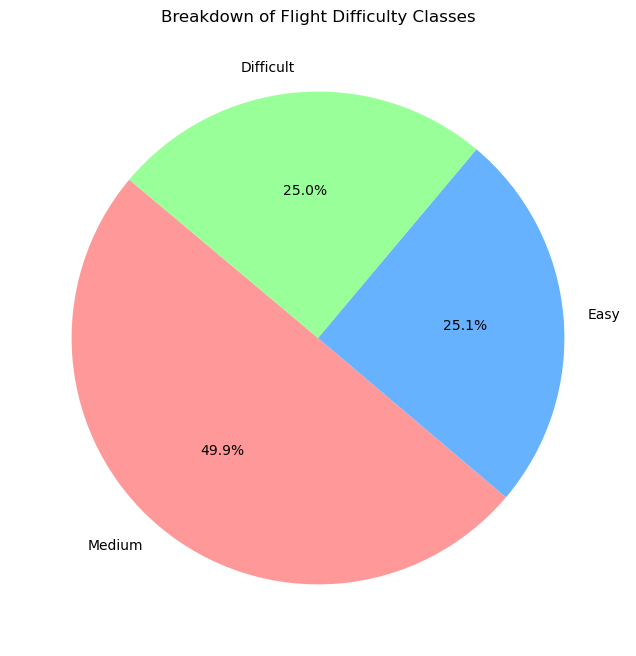

In [58]:
plt.figure(figsize=(8, 8))
class_counts = df_scaled['difficulty_class'].value_counts()
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=140, colors=['#FF9999','#66B2FF','#99FF99'])
plt.title('Breakdown of Flight Difficulty Classes')
plt.ylabel('') # Hides the 'difficulty_class' label on the y-axis
plt.savefig('difficulty_class_pie.png')
plt.show()

## 4. Visualization of Feature Weights

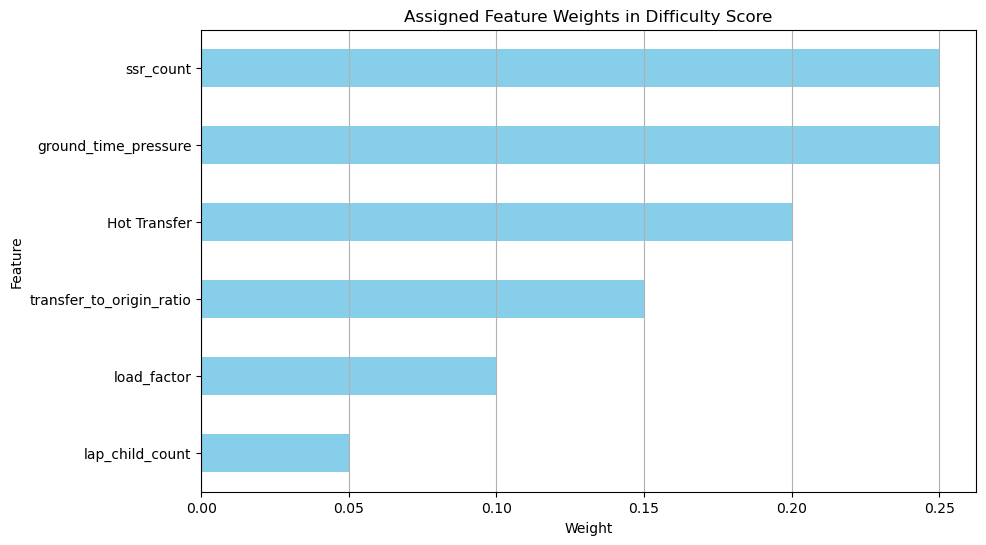

In [60]:

weights = {
    'ground_time_pressure': 0.25, 'ssr_count': 0.25, 'Hot Transfer': 0.20,
    'transfer_to_origin_ratio': 0.15, 'load_factor': 0.10, 'lap_child_count': 0.05
}
weights_s = pd.Series(weights)

plt.figure(figsize=(10, 6))
weights_s.sort_values().plot(kind='barh', color='skyblue')
plt.title('Assigned Feature Weights in Difficulty Score')
plt.xlabel('Weight')
plt.ylabel('Feature')
plt.grid(axis='x')
plt.savefig('feature_weights.png')
plt.show()

## 5. Top 10 most difficult destinations 

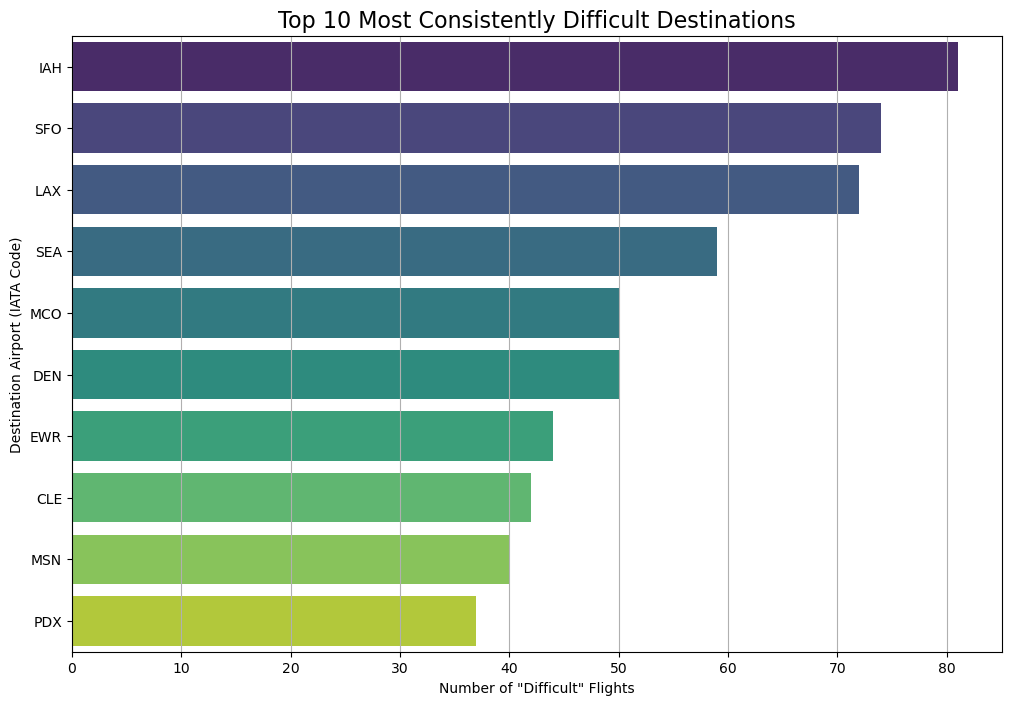

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

top_10_dests = difficult_destinations.head(10)

plt.figure(figsize=(12, 8))
sns.barplot(
    x=top_10_dests.values, 
    y=top_10_dests.index, 
    palette='viridis',
    hue=top_10_dests.index,   
    legend=False              
)

plt.title('Top 10 Most Consistently Difficult Destinations', fontsize=16)
plt.xlabel('Number of "Difficult" Flights')
plt.ylabel('Destination Airport (IATA Code)')
plt.grid(axis='x')

plt.savefig('top_10_difficult_destinations.png')

plt.show()